# Informer: Exchange Rate Forecasting

**Paper**: Informer: Beyond Efficient Transformer for Long Sequence Time-Series Forecasting (AAAI 2021 Best Paper)  
**Dataset**: Daily Exchange Rate (8 currency pairs, 1990–2010, N=7588)  
**Repo**: https://github.com/zhouhaoyi/Informer2020

---

## Dataset Structure
Our exchange rate dataset mirrors the ETT dataset structure:
- `date`: daily timestamps
- `0–6`: 7 exchange rate features  
- `OT`: target variable (same role as 'OT' / oil temperature in ETT)

## Forecasting Modes
| `--features` | Input | Output | Use Case |
|---|---|---|---|
| `M` | All 8 cols | All 8 cols | Multivariate → Multivariate |
| `S` | OT only | OT only | Univariate → Univariate |
| `MS` | All 8 cols | OT only | Multivariate → Univariate |

We run **both M and S** to match the paper's evaluation protocol.

## Setup
**Runtime → Change runtime type → GPU (T4/A100/V100)**

---
## Cell 1: Environment Setup

In [1]:
import shutil, os, subprocess, sys, warnings

# ── Step 1: Reset CWD to /content FIRST, then delete ─────────────────────────
os.chdir('/content')

for folder in ['/content/Informer2020']:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f'Deleted: {folder}')

# ── Step 2: Clone to explicit destination ─────────────────────────────────────
!git clone https://github.com/zhouhaoyi/Informer2020.git /content/Informer2020
os.chdir('/content/Informer2020')
print(f'CWD: {os.getcwd()}')

# ── Step 3: Install only what Colab is missing ────────────────────────────────
!pip install -q scikit-learn

# ── Step 4: Imports ───────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('=' * 70)
print('ENVIRONMENT')
print('=' * 70)
print(f'CWD     : {os.getcwd()}')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('=' * 70)

Cloning into '/content/Informer2020'...
remote: Enumerating objects: 590, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 590 (delta 6), reused 3 (delta 3), pack-reused 578 (from 2)
Receiving objects: 100% (590/590), 6.49 MiB | 16.41 MiB/s, done.
Resolving deltas: 100% (336/336), done.
CWD: /content/Informer2020
ENVIRONMENT
CWD     : /content/Informer2020
PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : NVIDIA A100-SXM4-80GB
VRAM    : 85.1 GB


---
## Cell 2: Upload & Explore Dataset

In [2]:
from google.colab import files, drive
import io

drive.mount('/content/drive')

SRC     = '/content/drive/MyDrive/2026 Winter STAD68/Project/Data/exchange_rate/exchange_rate.csv'
# print('Upload your exchange_rate.csv file...')
# uploaded = files.upload()

# filename = list(uploaded.keys())[0]
df = pd.read_csv(SRC)
df['date'] = pd.to_datetime(df['date'])

print(f'\nDataset loaded: {df.shape[0]} rows × {df.shape[1]} cols')
print(f'Date range   : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Columns      : {list(df.columns)}')
print(f'\nFirst 5 rows:')
df.head()

Mounted at /content/drive

Dataset loaded: 7588 rows × 9 cols
Date range   : 1990-01-01 → 2010-10-10
Columns      : ['date', '0', '1', '2', '3', '4', '5', '6', 'OT']

First 5 rows:


,date,0,1,2,3,4,5,6,OT
0,1990-01-01,0.7855,1.6110,0.861698,0.634196,0.211242,0.006838,0.525486,0.5930
1,1990-01-02,0.7818,1.6100,0.861104,0.633513,0.211242,0.006863,0.523972,0.5940
2,1990-01-03,0.7867,1.6293,0.861030,0.648508,0.211242,0.006975,0.526316,0.5973
3,1990-01-04,0.7860,1.6370,0.862069,0.650618,0.211242,0.006953,0.523834,0.5970
4,1990-01-05,0.7849,1.6530,0.861995,0.656254,0.211242,0.006940,0.527426,0.5985


---
## Cell 3: Exploratory Data Analysis

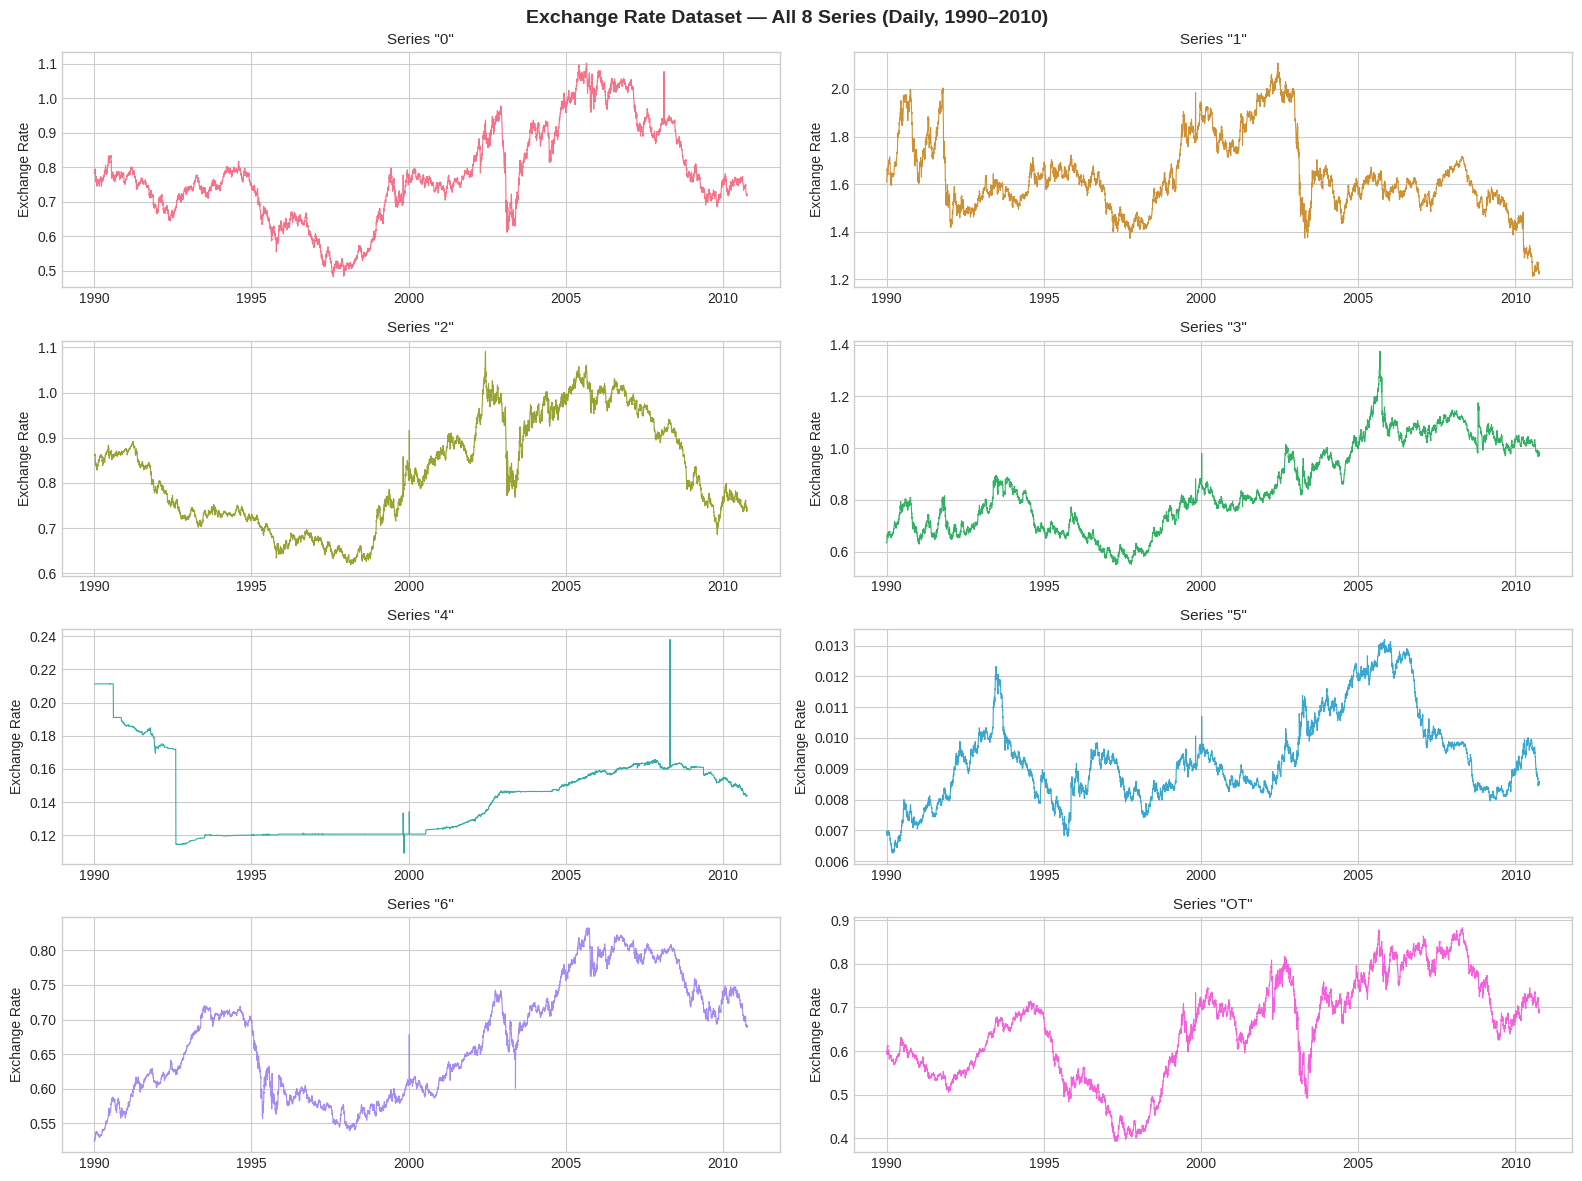


Descriptive Statistics:


,0,1,2,3,4,5,6,OT
count,7588.0000,7588.0000,7588.0000,7588.0000,7588.0000,7588.0000,7588.0000,7588.0000
mean,0.7770,1.6341,0.8218,0.8481,0.1428,0.0093,0.6697,0.6544
std,0.1366,0.1615,0.1171,0.1689,0.0240,0.0015,0.0828,0.1153
min,0.4833,1.2115,0.6186,0.5486,0.1093,0.0063,0.5238,0.3932
25%,0.7014,1.5329,0.7279,0.6969,0.1208,0.0083,0.5933,0.5660
50%,0.7614,1.6066,0.8116,0.8140,0.1452,0.0092,0.6628,0.6692
75%,0.8735,1.7076,0.9204,1.0140,0.1599,0.0100,0.7318,0.7349
max,1.1025,2.1090,1.0915,1.3741,0.2380,0.0132,0.8326,0.8824


In [3]:
feature_cols = ['0', '1', '2', '3', '4', '5', '6', 'OT']

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.suptitle('Exchange Rate Dataset — All 8 Series (Daily, 1990–2010)', fontsize=14, fontweight='bold')

for i, (col, ax) in enumerate(zip(feature_cols, axes.flat)):
    ax.plot(df['date'], df[col], linewidth=0.8, color=sns.color_palette('husl', 8)[i])
    ax.set_title(f'Series "{col}"', fontsize=11)
    ax.set_ylabel('Exchange Rate')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout()
plt.savefig('exchange_rate_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDescriptive Statistics:')
df[feature_cols].describe().round(4)

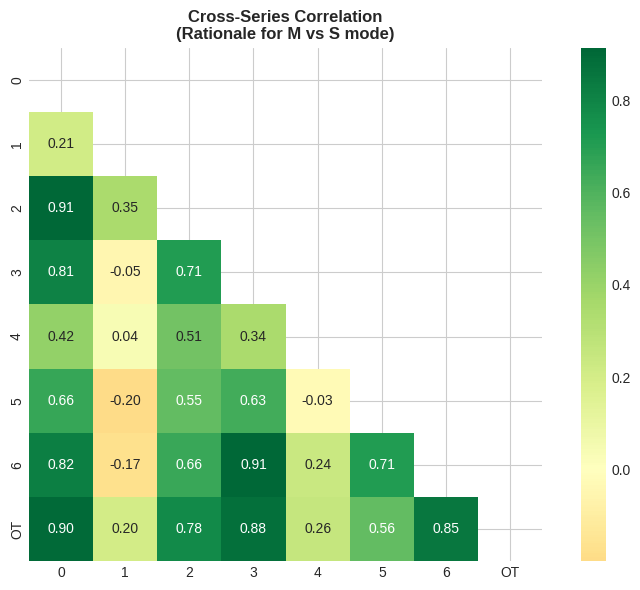

High-correlation pairs (|r|>0.7): 10
  0 ↔ 2: r=0.914
  3 ↔ 6: r=0.907
  0 ↔ OT: r=0.901
  3 ↔ OT: r=0.879
  6 ↔ OT: r=0.851

→ High correlation supports using M mode: cross-series info helps prediction.


In [4]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, square=True,
            xticklabels=feature_cols, yticklabels=feature_cols)
ax.set_title('Cross-Series Correlation\n(Rationale for M vs S mode)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('exchange_rate_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Note on M vs S
high_corr = [(feature_cols[i], feature_cols[j], corr.iloc[i,j])
             for i in range(len(feature_cols)) for j in range(i+1, len(feature_cols))
             if abs(corr.iloc[i,j]) > 0.7]
print(f'High-correlation pairs (|r|>0.7): {len(high_corr)}')
for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:5]:
    print(f'  {a} ↔ {b}: r={r:.3f}')
print('\n→ High correlation supports using M mode: cross-series info helps prediction.')

---
## Cell 4: Prepare Custom Dataset for Informer

The Informer repo expects a specific CSV structure identical to the ETT dataset.  
Our exchange rate data already matches (same `date` + feature columns + `OT` target), so we just copy it into the expected path.

In [5]:
# import shutil, os

# Save a clean copy to the Informer data directory
os.makedirs('data/ETT', exist_ok=True)
df.to_csv('data/ETT/exchange_rate.csv', index=False)

# Verify structure
check = pd.read_csv('data/ETT/exchange_rate.csv')
print('Saved to data/ETT/exchange_rate.csv')
print(f'Shape : {check.shape}')
print(f'Cols  : {list(check.columns)}')

# ── Dataset split (70/10/20 like ETTh1) ──────────────────────────────────────
n = len(df)
n_train = int(n * 0.7)
n_val   = int(n * 0.1)
n_test  = n - n_train - n_val

print(f'\nDataset split (mimicking ETTh1 12/4/4 month ratio):')
print(f'  Train : {n_train} samples ({df["date"].iloc[0].date()} → {df["date"].iloc[n_train-1].date()})')
print(f'  Val   : {n_val} samples')
print(f'  Test  : {n_test} samples → {df["date"].iloc[-1].date()}')

# Number of input/output features
enc_in = len(feature_cols)   # 8
dec_in = len(feature_cols)   # 8
c_out  = len(feature_cols)   # 8 for M mode, 1 for S mode
print(f'\nModel dimensions: enc_in={enc_in}, dec_in={dec_in}, c_out={c_out}')

Saved to data/ETT/exchange_rate.csv
Shape : (7588, 9)
Cols  : ['date', '0', '1', '2', '3', '4', '5', '6', 'OT']

Dataset split (mimicking ETTh1 12/4/4 month ratio):
  Train : 5311 samples (1990-01-01 → 2004-07-16)
  Val   : 758 samples
  Test  : 1519 samples → 2010-10-10

Model dimensions: enc_in=8, dec_in=8, c_out=8


---
## Cell 5: Register Custom Dataset in Informer Codebase

We need to add `'ExchangeRate'` as a valid dataset name in `main_informer.py`'s data dictionary.

In [6]:
# Read the existing data_dict from main_informer.py
with open('main_informer.py', 'r') as f:
    content = f.read()

# Check what data_dict looks like already
import re
match = re.search(r'data_dict\s*=\s*\{[^}]+\}', content)
if match:
    print('Found data_dict:')
    print(match.group())
else:
    # Search for 'ETTh1' context
    idx = content.find('ETTh1')
    print('ETTh1 context in main_informer.py:')
    print(content[max(0, idx-200):idx+300])

ETTh1 context in main_informer.py:
odel', type=str, required=True, default='informer',help='model of experiment, options: [informer, informerstack, informerlight(TBD)]')

parser.add_argument('--data', type=str, required=True, default='ETTh1', help='data')
parser.add_argument('--root_path', type=str, default='./data/ETT/', help='root path of the data file')
parser.add_argument('--data_path', type=str, default='ETTh1.csv', help='data file')    
parser.add_argument('--features', type=str, default='M', help='forecasting task, options


In [7]:
# Add ExchangeRate to data_dict (ETTh1-type, daily freq, custom path)
# Strategy: patch data/data_loader.py to handle our dataset

with open('data/data_loader.py', 'r') as f:
    loader_content = f.read()

# Show the Dataset_ETT_hour class signature to understand structure
idx = loader_content.find('class Dataset_ETT_hour')
print(loader_content[idx:idx+800])

class Dataset_ETT_hour(Dataset):
    def __init__(self, root_path, flag='train', size=None, 
                 features='S', data_path='ETTh1.csv', 
                 target='OT', scale=True, inverse=False, timeenc=0, freq='h', cols=None):
        # size [seq_len, label_len, pred_len]
        # info
        if size == None:
            self.seq_len = 24*4*4
            self.label_len = 24*4
            self.pred_len = 24*4
        else:
            self.seq_len = size[0]
            self.label_len = size[1]
            self.pred_len = size[2]
        # init
        assert flag in ['train', 'test', 'val']
        type_map = {'train':0, 'val':1, 'test':2}
        self.set_type = type_map[flag]
        
        self.features = features
        self.target = target
        self.scale = scale
   


In [8]:
# The cleanest approach: patch main_informer.py to treat 'ExchangeRate'
# the same as ETTh1 (same Dataset_ETT_hour loader, daily frequency)


# Patch exp/exp_informer.py — it has its own data_dict
with open('exp/exp_informer.py', 'r') as f:
    exp_content = f.read()

# Find the equivalent line in exp_informer.py
print('ETTh1 context in exp_informer.py:')
for i, line in enumerate(exp_content.split('\n')):
    if 'ETTh1' in line:
        print(f'Line {i}: {line}')


with open('exp/exp_informer.py', 'r') as f:
    exp_content = f.read()

old_snippet = "'ETTh1':Dataset_ETT_hour"
new_snippet = "'ETTh1':Dataset_ETT_hour,\n            'ExchangeRate':Dataset_ETT_hour"

if old_snippet in exp_content:
    new_exp_content = exp_content.replace(old_snippet, new_snippet)
    with open('exp/exp_informer.py', 'w') as f:
        f.write(new_exp_content)
    print('✓ Patched exp/exp_informer.py')
else:
    # Spacing might differ slightly — try without spaces around colon
    print('Exact snippet not found. Lines containing ETTh1:')
    for i, line in enumerate(exp_content.split('\n')):
        if 'ETTh1' in line:
            print(f'  Line {i}: {repr(line)}')  # repr() shows exact whitespace

# Verify both files
for fpath in ['main_informer.py', 'exp/exp_informer.py']:
    with open(fpath) as f:
        found = 'ExchangeRate' in f.read()
    print(f'ExchangeRate in {fpath}: {found}')




ETTh1 context in exp_informer.py:
Line 63:             'ETTh1':Dataset_ETT_hour,
✓ Patched exp/exp_informer.py
ExchangeRate in main_informer.py: False
ExchangeRate in exp/exp_informer.py: True


In [9]:
with open('data/data_loader.py', 'r') as f:
    loader = f.read()

# Find where border1/border2 are defined in Dataset_ETT_hour
for i, line in enumerate(loader.split('\n')):
    if any(k in line for k in ['border1', 'border2', 'num_train', 'num_test', 'num_vali']):
        print(f'Line {i}: {line}')

Line 49:         border1s = [0, 12*30*24 - self.seq_len, 12*30*24+4*30*24 - self.seq_len]
Line 50:         border2s = [12*30*24, 12*30*24+4*30*24, 12*30*24+8*30*24]
Line 51:         border1 = border1s[self.set_type]
Line 52:         border2 = border2s[self.set_type]
Line 61:             train_data = df_data[border1s[0]:border2s[0]]
Line 67:         df_stamp = df_raw[['date']][border1:border2]
Line 71:         self.data_x = data[border1:border2]
Line 73:             self.data_y = df_data.values[border1:border2]
Line 75:             self.data_y = data[border1:border2]
Line 135:         border1s = [0, 12*30*24*4 - self.seq_len, 12*30*24*4+4*30*24*4 - self.seq_len]
Line 136:         border2s = [12*30*24*4, 12*30*24*4+4*30*24*4, 12*30*24*4+8*30*24*4]
Line 137:         border1 = border1s[self.set_type]
Line 138:         border2 = border2s[self.set_type]
Line 147:             train_data = df_data[border1s[0]:border2s[0]]
Line 153:         df_stamp = df_raw[['date']][border1:border2]
Line 157:

In [10]:
with open('data/data_loader.py', 'r') as f:
    loader = f.read()

print('Dataset_Custom exists:', 'Dataset_Custom' in loader)
print('Dataset_Custom imported in exp_informer.py:',
      'Dataset_Custom' in open('exp/exp_informer.py').read())

Dataset_Custom exists: True
Dataset_Custom imported in exp_informer.py: True


In [11]:
# Fix exp/exp_informer.py
with open('exp/exp_informer.py', 'r') as f:
    content = f.read()

# Replace our entry to use Dataset_Custom
new_content = content.replace(
    "'ExchangeRate':Dataset_ETT_hour",
    "'ExchangeRate':Dataset_Custom"
)

# Also make sure Dataset_Custom is imported at the top
if 'Dataset_Custom' not in content:
    new_content = new_content.replace(
        'from data.data_loader import Dataset_ETT_hour',
        'from data.data_loader import Dataset_ETT_hour, Dataset_Custom'
    )

with open('exp/exp_informer.py', 'w') as f:
    f.write(new_content)
print('✓ exp/exp_informer.py patched to use Dataset_Custom')

# Fix main_informer.py
with open('main_informer.py', 'r') as f:
    content = f.read()

new_content = content.replace(
    "'ExchangeRate':{'data':'exchange_rate.csv','T':'OT','M':[8,8,8],'S':[1,1,1],'MS':[8,8,1]}",
    "'ExchangeRate':{'data':'exchange_rate.csv','T':'OT','M':[8,8,8],'S':[1,1,1],'MS':[8,8,1]}"
)
# Dataset_Custom handles its own splits via size parameter, no change needed in main

with open('main_informer.py', 'w') as f:
    f.write(new_content)

# Verify
for fpath in ['main_informer.py', 'exp/exp_informer.py']:
    with open(fpath) as f:
        c = f.read()
    print(f'{fpath} → ExchangeRate:{c[c.find("ExchangeRate"):c.find("ExchangeRate")+40] if "ExchangeRate" in c else "NOT FOUND"}')

✓ exp/exp_informer.py patched to use Dataset_Custom
main_informer.py → ExchangeRate:NOT FOUND
exp/exp_informer.py → ExchangeRate:ExchangeRate':Dataset_Custom,
          


---
## Cell 6: Define Run Configuration

Prediction horizons follow the paper's LSTF protocol. For daily data, the equivalent
of ETTh1's {24, 48, 168, 336, 720} hour horizons maps to {24, 48, 168, 336, 720} **days**.

In [12]:
# ── Shared settings for all experiments ─────────────────────────────────────
BASE_ARGS = {
    '--model':       'informer',
    '--data':        'ExchangeRate',
    '--root_path':   './data/ETT/',
    '--data_path':   'exchange_rate.csv',
    '--freq':        'd',
    '--e_layers':    '2',
    '--d_layers':    '1',
    '--attn':        'prob',
    # enc_in, dec_in, c_out intentionally omitted — set per-mode in build_cmd
    '--factor':      '3',
    '--train_epochs':'6',
    '--batch_size':  '32',
    '--itr':         '1',
}
if torch.cuda.is_available():
    BASE_ARGS['--use_gpu'] = 'True'
    # BASE_ARGS['--use_amp'] = ''    # flag with no value

# ── M mode (multivariate → multivariate): c_out=8 ────────────────────────────
M_EXPERIMENTS = [
    # (seq_len, label_len, pred_len)  — mirrors ETTh1 M scripts
    (144,  144,  96)
]

# ── S mode (univariate → univariate): c_out=1, target=OT ─────────────────────
S_EXPERIMENTS = [
    (720, 168, 24),
    (720, 168, 48),
    (720, 336, 168),
    (720, 336, 336),
    (720, 336, 720),
]

def build_cmd(mode, seq_len, label_len, pred_len):
    args = dict(BASE_ARGS)
    args['--features']  = mode
    args['--seq_len']   = str(seq_len)
    args['--label_len'] = str(label_len)
    args['--pred_len']  = str(pred_len)
    args['--des']       = f'Exchange_{mode}'
    if mode == 'M':
        args['--enc_in'] = '8'
        args['--dec_in'] = '8'
        args['--c_out']  = '8'
    else:  # S
        args['--enc_in'] = '1'   # ← S mode: only the target column
        args['--dec_in'] = '1'   # ← S mode: only the target column
        args['--c_out']  = '1'
        args['--target'] = 'OT'
    parts = ['python -u main_informer.py']
    for k, v in args.items():
        parts.append(k)
        if v != '':
            parts.append(v)
    return ' '.join(parts)

print('Sample M command:')
print(build_cmd('M', 48, 48, 24))
print('\nSample S command:')
print(build_cmd('S', 720, 168, 24))

Sample M command:
python -u main_informer.py --model informer --data ExchangeRate --root_path ./data/ETT/ --data_path exchange_rate.csv --freq d --e_layers 2 --d_layers 1 --attn prob --factor 3 --train_epochs 6 --batch_size 32 --itr 1 --use_gpu True --features M --seq_len 48 --label_len 48 --pred_len 24 --des Exchange_M --enc_in 8 --dec_in 8 --c_out 8

Sample S command:
python -u main_informer.py --model informer --data ExchangeRate --root_path ./data/ETT/ --data_path exchange_rate.csv --freq d --e_layers 2 --d_layers 1 --attn prob --factor 3 --train_epochs 6 --batch_size 32 --itr 1 --use_gpu True --features S --seq_len 720 --label_len 168 --pred_len 24 --des Exchange_S --enc_in 1 --dec_in 1 --c_out 1 --target OT


In [13]:
!sed -i 's/np\.Inf/np.inf/g' utils/tools.py
print('✓ Fixed np.Inf → np.inf in utils/tools.py')

# Verify
!grep -n 'np.Inf\|np.inf' utils/tools.py

✓ Fixed np.Inf → np.inf in utils/tools.py
26:        self.val_loss_min = np.inf


---
## Cell 7: Quick Single Run (S mode, pred_len=24) — Sanity Check

In [14]:
import subprocess, re

def run_experiment(mode, seq_len, label_len, pred_len, verbose=True):
    """Run one Informer experiment, printing epoch losses and returning metrics."""
    cmd = build_cmd(mode, seq_len, label_len, pred_len)
    label = f'{mode} seq={seq_len} label={label_len} pred={pred_len}'
    print(f'\n{"="*65}')
    print(f'Running: {label}')
    print(f'{"="*65}')
    if verbose:
        print(f'CMD: {cmd}\n')

    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    output = result.stdout + result.stderr

    # ── Parse per-epoch train/val/test losses ─────────────────────────────
    # Informer prints lines like:
    #   Epoch: 1 cost time: 3.45s | Train Loss: 0.4123 Vali Loss: 0.3821 Test Loss: 0.3956
    epoch_pattern = re.compile(
        r'Epoch:\s*(\d+).*?Train Loss:\s*([\d.]+)\s+Vali Loss:\s*([\d.]+)\s+Test Loss:\s*([\d.]+)'
    )
    epoch_rows = []
    for line in output.split('\n'):
        m = epoch_pattern.search(line)
        if m:
            epoch_rows.append({
                'epoch':      int(m.group(1)),
                'train_loss': float(m.group(2)),
                'vali_loss':  float(m.group(3)),
                'test_loss':  float(m.group(4)),
            })

    # ── Print epoch table ─────────────────────────────────────────────────
    if epoch_rows:
        print(f'\n{"Epoch":>6}  {"Train Loss":>12}  {"Vali Loss":>12}  {"Test Loss":>12}')
        print('-' * 50)
        for row in epoch_rows:
            print(f'{row["epoch"]:>6}  {row["train_loss"]:>12.6f}  {row["vali_loss"]:>12.6f}  {row["test_loss"]:>12.6f}')
    elif verbose:
        lines = output.strip().split('\n')
        for line in lines[-40:]:
            print(line)

    # ── Parse final test MSE/MAE ──────────────────────────────────────────
    mse_match = re.findall(r'mse:([\d.]+)', output)
    mae_match = re.findall(r'mae:([\d.]+)', output)
    mse = float(mse_match[-1]) if mse_match else None
    mae = float(mae_match[-1]) if mae_match else None

    if mse is not None:
        print(f'\n  -> Test MSE: {mse:.6f}  |  Test MAE: {mae:.6f}')

    return {
        'mode': mode, 'seq_len': seq_len, 'label_len': label_len,
        'pred_len': pred_len, 'mse': mse, 'mae': mae,
        'epoch_losses': epoch_rows, 'output': output,
    }

# Sanity check: fast S mode run with shortest horizon
sanity = run_experiment('S', 720, 168, 24, verbose=True)
print(f'\n-> Sanity check MSE={sanity["mse"]}, MAE={sanity["mae"]}')



Running: S seq=720 label=168 pred=24
CMD: python -u main_informer.py --model informer --data ExchangeRate --root_path ./data/ETT/ --data_path exchange_rate.csv --freq d --e_layers 2 --d_layers 1 --attn prob --factor 3 --train_epochs 6 --batch_size 32 --itr 1 --use_gpu True --features S --seq_len 720 --label_len 168 --pred_len 24 --des Exchange_S --enc_in 1 --dec_in 1 --c_out 1 --target OT


 Epoch    Train Loss     Vali Loss     Test Loss
--------------------------------------------------
     1      0.234123      0.294243      0.307474
     2      0.044248      0.792975      0.590121
     3      0.026183      0.768943      0.653407
     4      0.022197      0.903606      0.724185

  -> Test MSE: 0.306973  |  Test MAE: 0.489647

-> Sanity check MSE=0.30697280168533325, MAE=0.48964670300483704


---
## Cell 8: Full Experiment Suite (M + S Modes)

In [16]:
all_results = []

# ── M mode runs ──────────────────────────────────────────────────────────
print('\n' + '#'*65)
print('# MULTIVARIATE MODE (M): 8 -> 8 columns')
print('#'*65)
for (seq_len, label_len, pred_len) in M_EXPERIMENTS:
    res = run_experiment('M', seq_len, label_len, pred_len, verbose=True)
    all_results.append(res)

# ── S mode runs ──────────────────────────────────────────────────────────
# print('\n' + '#'*65)
# print('# UNIVARIATE MODE (S): OT -> OT only')
# print('#'*65)
# for (seq_len, label_len, pred_len) in S_EXPERIMENTS:
#     res = run_experiment('S', seq_len, label_len, pred_len, verbose=True)
#     all_results.append(res)

print('\n' + '='*65)
print('ALL EXPERIMENTS COMPLETE — SUMMARY')
print('='*65)
print(f'\n{"Mode":>4}  {"pred":>5}  {"MSE":>10}  {"MAE":>10}')
print('-' * 36)
for r in all_results:
    mse_str = f'{r["mse"]:.6f}' if r['mse'] is not None else '   FAILED'
    mae_str = f'{r["mae"]:.6f}' if r['mae'] is not None else '   FAILED'
    print(f'{r["mode"]:>4}  {r["pred_len"]:>5}  {mse_str:>10}  {mae_str:>10}')



#################################################################
# MULTIVARIATE MODE (M): 8 -> 8 columns
#################################################################

Running: M seq=144 label=144 pred=96
CMD: python -u main_informer.py --model informer --data ExchangeRate --root_path ./data/ETT/ --data_path exchange_rate.csv --freq d --e_layers 2 --d_layers 1 --attn prob --factor 3 --train_epochs 6 --batch_size 32 --itr 1 --use_gpu True --features M --seq_len 144 --label_len 144 --pred_len 96 --des Exchange_M --enc_in 8 --dec_in 8 --c_out 8


 Epoch    Train Loss     Vali Loss     Test Loss
--------------------------------------------------
     1      0.157919      1.198758      1.028367
     2      0.063590      1.426426      1.164881
     3      0.042872      1.127773      1.066876
     4      0.036566      1.264373      1.140468
     5      0.034120      1.229158      1.126216
     6      0.032520      1.198858      1.107968

  -> Test MSE: 1.067510  |  Test MAE: 0.830589

A

---
## Cell 9: Results Table

In [17]:
results_df = pd.DataFrame([
    {
        'Mode':      r['mode'],
        'Seq Len':   r['seq_len'],
        'Label Len': r['label_len'],
        'Pred Len':  r['pred_len'],
        'MSE':       r['mse'],
        'MAE':       r['mae'],
    }
    for r in all_results
])
results_df.to_csv('informer_exchange_results.csv', index=False)

# Save per-epoch loss curves for all experiments
epoch_records = []
for r in all_results:
    for row in r.get('epoch_losses', []):
        epoch_records.append({
            'mode':       r['mode'],
            'pred_len':   r['pred_len'],
            'epoch':      row['epoch'],
            'train_loss': row['train_loss'],
            'vali_loss':  row['vali_loss'],
            'test_loss':  row['test_loss'],
        })
epoch_df = pd.DataFrame(epoch_records)
epoch_df.to_csv('informer_epoch_losses.csv', index=False)

print('=' * 65)
print('INFORMER — EXCHANGE RATE RESULTS SUMMARY')
print('=' * 65)
for mode in ['M', 'S']:
    sub = results_df[results_df['Mode'] == mode][['Pred Len', 'MSE', 'MAE']]
    if not sub.empty:
        print(f'\n{mode} Mode ({"Multivariate" if mode == "M" else "Univariate"}):')
        print(sub.to_string(index=False))

print('\nSaved: informer_exchange_results.csv')
print('Saved: informer_epoch_losses.csv')
results_df


INFORMER — EXCHANGE RATE RESULTS SUMMARY

M Mode (Multivariate):
 Pred Len     MSE      MAE
       96 1.06751 0.830589

Saved: informer_exchange_results.csv
Saved: informer_epoch_losses.csv


,Mode,Seq Len,Label Len,Pred Len,MSE,MAE
0,M,144,144,96,1.06751,0.830589


---
## Cell 10: Load & Inspect Saved Predictions

In [ ]:
import glob

# Informer saves predictions/trues as .npy in checkpoints/<setting>/
result_dirs = sorted(glob.glob('results/*Exchange*'))
print(f'Found {len(result_dirs)} result directories:')
for d in result_dirs:
    files_in = os.listdir(d) if os.path.isdir(d) else []
    print(f'  {d} → {files_in}')

def load_pred_true(result_dir):
    """Load predictions and ground truth from Informer result folder."""
    pred = np.load(os.path.join(result_dir, 'pred.npy'))   # shape: (N, pred_len, n_features)
    true = np.load(os.path.join(result_dir, 'true.npy'))
    return pred, true

# Load first available result
if result_dirs:
    pred_sample, true_sample = load_pred_true(result_dirs[0])
    print(f'\nSample result shape  — pred: {pred_sample.shape}, true: {true_sample.shape}')
    print('(N_windows, pred_len, n_features)')

---
## Cell 11: Comprehensive Visualizations

### 11a: Forecast vs Ground Truth — Full Test Set (OT column)

In [ ]:
def plot_full_test_predictions(result_dir, pred_len, mode='S', target_col_idx=0,
                               col_name='OT'):
    """
    Plot the full test set: ground truth vs Informer predictions.
    For S mode: only 1 output column. For M mode: select target_col_idx.
    """
    if not os.path.exists(result_dir):
        print(f'Result dir not found: {result_dir}')
        return

    pred, true = load_pred_true(result_dir)
    # pred/true shape: (N_windows, pred_len, n_out)
    n_windows = pred.shape[0]

    # Reconstruct continuous test signal by taking 1-step-ahead predictions
    # (first forecast step from each window, stride=1)
    pred_1step = pred[:, 0, target_col_idx]   # shape (N_windows,)
    true_1step = true[:, 0, target_col_idx]

    # Also get the multi-step sequence for a selected window
    window_idx = n_windows // 2   # middle of test set
    pred_window = pred[window_idx, :, target_col_idx]
    true_window = true[window_idx, :, target_col_idx]

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        f'Informer — Exchange Rate ("{col_name}") | Mode={mode} | pred_len={pred_len}',
        fontsize=14, fontweight='bold'
    )
    gs = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Plot 1: Full test set — 1-step-ahead ──────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    x = np.arange(len(true_1step))
    ax1.plot(x, true_1step, label='Ground Truth', color='steelblue', linewidth=0.9, alpha=0.9)
    ax1.plot(x, pred_1step, label='Informer (1-step)', color='tomato',
             linewidth=0.9, alpha=0.8, linestyle='--')
    ax1.set_title(f'Full Test Set — 1-Step-Ahead Forecast ({n_windows} windows)', fontsize=11)
    ax1.set_xlabel('Test Window Index')
    ax1.set_ylabel('Normalized Value')
    ax1.legend()

    # ── Plot 2: Multi-step forecast for selected window ───────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    steps = np.arange(1, pred_len + 1)
    ax2.plot(steps, true_window, 'o-', label='Ground Truth', color='steelblue',
             markersize=4, linewidth=1.5)
    ax2.plot(steps, pred_window, 's--', label='Informer', color='tomato',
             markersize=4, linewidth=1.5)
    ax2.set_title(f'Multi-Step Forecast (Window {window_idx})', fontsize=10)
    ax2.set_xlabel('Forecast Horizon (days)')
    ax2.set_ylabel('Normalized Value')
    ax2.legend()

    # ── Plot 3: Prediction error over horizon ─────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    # Average MAE across all windows at each horizon step
    mae_per_step = np.mean(np.abs(pred[:, :, target_col_idx] - true[:, :, target_col_idx]), axis=0)
    ax3.plot(np.arange(1, pred_len + 1), mae_per_step, color='darkorange', linewidth=1.8, marker='o', markersize=3)
    ax3.fill_between(np.arange(1, pred_len + 1), mae_per_step, alpha=0.3, color='darkorange')
    ax3.set_title('MAE vs Forecast Horizon (avg over test set)', fontsize=10)
    ax3.set_xlabel('Forecast Horizon (days)')
    ax3.set_ylabel('MAE')

    # ── Plot 4: Residual distribution ─────────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    residuals = (pred[:, :, target_col_idx] - true[:, :, target_col_idx]).flatten()
    ax4.hist(residuals, bins=60, color='mediumpurple', alpha=0.75, edgecolor='white')
    ax4.axvline(0, color='black', linestyle='--', linewidth=1.2)
    ax4.axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.2,
                label=f'Mean={residuals.mean():.4f}')
    ax4.set_title('Residual Distribution (Pred − True)', fontsize=10)
    ax4.set_xlabel('Residual')
    ax4.set_ylabel('Count')
    ax4.legend()

    # ── Plot 5: Scatter (predicted vs actual) ─────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    p_flat = pred[:, :, target_col_idx].flatten()
    t_flat = true[:, :, target_col_idx].flatten()
    # Subsample for clarity
    idx_sub = np.random.choice(len(p_flat), size=min(3000, len(p_flat)), replace=False)
    ax5.scatter(t_flat[idx_sub], p_flat[idx_sub], alpha=0.3, s=8, color='teal')
    lims = [min(t_flat.min(), p_flat.min()), max(t_flat.max(), p_flat.max())]
    ax5.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
    # R² score
    ss_res = np.sum((t_flat - p_flat) ** 2)
    ss_tot = np.sum((t_flat - t_flat.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    ax5.set_title(f'Predicted vs Actual (R²={r2:.4f})', fontsize=10)
    ax5.set_xlabel('Actual')
    ax5.set_ylabel('Predicted')
    ax5.legend()

    # ── Final metrics annotation ──────────────────────────────────────────────
    mse = np.mean((pred[:, :, target_col_idx] - true[:, :, target_col_idx]) ** 2)
    mae = np.mean(np.abs(pred[:, :, target_col_idx] - true[:, :, target_col_idx]))
    fig.text(0.5, 0.01,
             f'Test MSE={mse:.6f}  |  Test MAE={mae:.6f}  |  R²={r2:.4f}',
             ha='center', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    save_path = f'informer_viz_{mode}_pred{pred_len}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')
    return {'mse': mse, 'mae': mae, 'r2': r2}

# Visualize S mode, pred=24 (our sanity check)
s_dirs = [d for d in result_dirs if 'features_S' in d and 'pl24' in d]
if s_dirs:
    metrics = plot_full_test_predictions(s_dirs[0], pred_len=24, mode='S',
                                         target_col_idx=0, col_name='OT')
else:
    print('No S-mode pred=24 results found yet. Run Cell 8 first.')

### 11b: Visualize All Prediction Horizons

In [ ]:
def plot_multi_horizon_comparison(result_dirs, mode='S', target_col_idx=0):
    """
    Side-by-side comparison of forecast quality across prediction horizons.
    """
    # Filter by mode
    mode_dirs = [d for d in result_dirs if f'features_{mode}' in d]
    if not mode_dirs:
        print(f'No {mode}-mode results found.')
        return

    # Extract pred_len from directory name
    def get_pred_len(d):
        m = re.search(r'pl(\d+)', d)
        return int(m.group(1)) if m else 0
    mode_dirs = sorted(mode_dirs, key=get_pred_len)

    n_plots = len(mode_dirs)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    fig.suptitle(
        f'Informer ({mode} Mode) — Forecast Quality Across Horizons\n'
        f'Exchange Rate Dataset (target: OT)',
        fontsize=13, fontweight='bold'
    )

    metrics_list = []
    for ax, d in zip(axes, mode_dirs):
        pl = get_pred_len(d)
        pred, true = load_pred_true(d)
        # Show the middle window's multi-step forecast
        w = pred.shape[0] // 2
        p = pred[w, :, target_col_idx]
        t = true[w, :, target_col_idx]
        steps = np.arange(1, pl + 1)
        ax.plot(steps, t, 'o-', color='steelblue', markersize=3, linewidth=1.5, label='True')
        ax.plot(steps, p, 's--', color='tomato', markersize=3, linewidth=1.5, label='Pred')
        mse = np.mean((pred[:, :, target_col_idx] - true[:, :, target_col_idx]) ** 2)
        mae = np.mean(np.abs(pred[:, :, target_col_idx] - true[:, :, target_col_idx]))
        ax.set_title(f'pred_len={pl}\nMSE={mse:.4f} MAE={mae:.4f}', fontsize=9)
        ax.set_xlabel('Horizon (days)')
        ax.set_ylabel('Normalized Value')
        ax.legend(fontsize=8)
        metrics_list.append({'pred_len': pl, 'mse': mse, 'mae': mae})

    plt.tight_layout()
    plt.savefig(f'informer_horizon_comparison_{mode}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return pd.DataFrame(metrics_list)

if result_dirs:
    m_metrics = plot_multi_horizon_comparison(result_dirs, mode='M')
    s_metrics = plot_multi_horizon_comparison(result_dirs, mode='S')
else:
    print('Run Cell 8 first to generate results.')

### 11c: MSE/MAE vs Prediction Horizon (Paper-Style Plot)

In [ ]:
def plot_performance_vs_horizon(results_df):
    """
    Recreate the paper's Fig 1b style: MSE vs prediction length for M and S modes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Informer — Exchange Rate Dataset\nForecasting Performance vs Prediction Horizon',
                 fontsize=13, fontweight='bold')

    for ax, metric in zip(axes, ['MSE', 'MAE']):
        for mode, color, marker in [('M', 'steelblue', 'o'), ('S', 'tomato', 's')]:
            sub = results_df[results_df['Mode'] == mode].sort_values('Pred Len')
            if sub.empty or sub[metric].isna().all():
                continue
            ax.plot(sub['Pred Len'], sub[metric],
                    label=f'Informer ({mode} mode)',
                    color=color, marker=marker, markersize=7,
                    linewidth=2, linestyle='-')
            # Annotate each point
            for _, row in sub.iterrows():
                if pd.notna(row[metric]):
                    ax.annotate(f'{row[metric]:.3f}',
                                xy=(row['Pred Len'], row[metric]),
                                xytext=(5, 5), textcoords='offset points', fontsize=8)

        ax.set_xlabel('Prediction Horizon (days)', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_title(f'{metric} vs Prediction Horizon', fontsize=11)
        ax.legend(fontsize=10)
        ax.set_xticks([24, 48, 168, 336, 720])
        ax.set_xticklabels(['24d', '48d', '168d', '336d', '720d'])

    plt.tight_layout()
    plt.savefig('informer_performance_vs_horizon.png', dpi=150, bbox_inches='tight')
    plt.show()

if 'results_df' in dir() and not results_df.empty:
    plot_performance_vs_horizon(results_df)
else:
    print('Run Cell 9 first to build results_df.')

---
## Cell 12: Temporal Error Analysis — Where Does the Model Struggle?

In [ ]:
def plot_temporal_error_analysis(result_dir, pred_len, mode='S', target_col_idx=0):
    """
    Analyse how prediction error varies over the test set in time.
    Useful for understanding if the model struggles during volatile periods.
    """
    if not os.path.exists(result_dir):
        print(f'Not found: {result_dir}')
        return

    pred, true = load_pred_true(result_dir)
    n_windows = pred.shape[0]

    # Per-window mean absolute error
    window_mae = np.mean(np.abs(
        pred[:, :, target_col_idx] - true[:, :, target_col_idx]
    ), axis=1)  # (N_windows,)

    # Corresponding ground truth for reference (first step per window)
    true_series = true[:, 0, target_col_idx]

    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(
        f'Temporal Error Analysis — Informer {mode} mode | pred_len={pred_len}\n'
        f'Exchange Rate (OT column)',
        fontsize=13, fontweight='bold'
    )

    x = np.arange(n_windows)

    # Panel 1: Ground truth over test period
    axes[0].plot(x, true_series, color='steelblue', linewidth=0.9)
    axes[0].set_ylabel('OT (Normalized)', fontsize=10)
    axes[0].set_title('Ground Truth — Test Set', fontsize=10)

    # Panel 2: Per-window MAE
    axes[1].plot(x, window_mae, color='darkorange', linewidth=0.8, alpha=0.8)
    axes[1].fill_between(x, window_mae, alpha=0.25, color='darkorange')
    # Rolling average
    roll_window = max(5, n_windows // 50)
    rolling_mae = pd.Series(window_mae).rolling(roll_window, center=True).mean()
    axes[1].plot(x, rolling_mae, color='red', linewidth=2, label=f'Rolling MAE (w={roll_window})')
    axes[1].set_ylabel('MAE per Window', fontsize=10)
    axes[1].set_title('Prediction Error Over Time', fontsize=10)
    axes[1].legend()
    # Mark high-error regions
    threshold = np.percentile(window_mae, 90)
    high_error_idx = np.where(window_mae > threshold)[0]
    axes[1].axhline(threshold, color='black', linestyle=':', linewidth=1,
                    label=f'P90 threshold={threshold:.4f}')

    # Panel 3: Rolling volatility of ground truth (std of returns)
    returns = np.diff(true_series, prepend=true_series[0])
    roll_vol = pd.Series(np.abs(returns)).rolling(30, center=True).mean()
    axes[2].plot(x, roll_vol, color='purple', linewidth=0.9)
    axes[2].set_ylabel('Rolling Volatility (|ΔOT|)', fontsize=10)
    axes[2].set_xlabel('Test Window Index', fontsize=10)
    axes[2].set_title('Market Volatility vs Forecast Error\n(higher volatility → harder to forecast)', fontsize=10)

    # Correlation annotation
    corr = np.corrcoef(window_mae, roll_vol.fillna(0).values)[0, 1]
    axes[2].text(0.02, 0.92, f'Corr(Error, Volatility)={corr:.3f}',
                 transform=axes[2].transAxes, fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow'))

    plt.tight_layout()
    plt.savefig(f'informer_temporal_error_{mode}_pred{pred_len}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize temporal errors for S mode pred=24
if s_dirs:
    plot_temporal_error_analysis(s_dirs[0], pred_len=24, mode='S', target_col_idx=0)
else:
    print('Run experiments first.')

---
## Cell 13: Multivariate (M mode) — Per-Feature Breakdown

In [ ]:
def plot_multivariate_breakdown(result_dir, pred_len, feature_names=None):
    """
    For M mode: show forecast quality broken down by each currency pair.
    """
    if not os.path.exists(result_dir):
        print(f'Not found: {result_dir}')
        return

    pred, true = load_pred_true(result_dir)
    n_features = pred.shape[2]
    if feature_names is None:
        feature_names = [str(i) for i in range(n_features - 1)] + ['OT']

    # Per-feature MSE and MAE
    per_feat_mse = np.mean((pred - true) ** 2, axis=(0, 1))  # (n_features,)
    per_feat_mae = np.mean(np.abs(pred - true), axis=(0, 1))

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(
        f'Informer M Mode — Per-Series Forecast (pred_len={pred_len})\n'
        f'Exchange Rate Dataset: 8 Currency Pairs',
        fontsize=13, fontweight='bold'
    )

    colors = sns.color_palette('husl', n_features)
    w = pred.shape[0] // 2  # middle test window

    for idx, (ax, fname, color) in enumerate(zip(axes.flat, feature_names, colors)):
        steps = np.arange(1, pred_len + 1)
        ax.plot(steps, true[w, :, idx], 'o-', color=color, markersize=3,
                linewidth=1.5, label='True', alpha=0.9)
        ax.plot(steps, pred[w, :, idx], 's--', color='gray', markersize=3,
                linewidth=1.2, label='Pred', alpha=0.9)
        ax.set_title(
            f'Series "{fname}"\nMSE={per_feat_mse[idx]:.4f} MAE={per_feat_mae[idx]:.4f}',
            fontsize=9
        )
        ax.set_xlabel('Horizon')
        ax.set_ylabel('Norm. Value')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'informer_multivariate_breakdown_pred{pred_len}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bar chart: MSE per series
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    for ax2, metric, values in zip(axes2, ['MSE', 'MAE'], [per_feat_mse, per_feat_mae]):
        bars = ax2.bar(feature_names, values, color=colors, edgecolor='white', linewidth=0.5)
        ax2.bar_label(bars, fmt='%.4f', fontsize=8)
        ax2.set_title(f'Per-Series {metric} (pred_len={pred_len})', fontsize=11)
        ax2.set_xlabel('Currency Pair')
        ax2.set_ylabel(metric)
    plt.tight_layout()
    plt.savefig(f'informer_per_series_{pred_len}.png', dpi=150, bbox_inches='tight')
    plt.show()

m_dirs = [d for d in result_dirs if 'features_M' in d and 'pl24' in d]
if m_dirs:
    plot_multivariate_breakdown(m_dirs[0], pred_len=24, feature_names=feature_cols)
else:
    print('No M-mode pred=24 results found yet.')

---
## Cell 14: Save All Results & Download

In [ ]:
import zipfile
from google.colab import files

# Collect all generated files
output_files = (
    glob.glob('informer_*.png') +
    glob.glob('exchange_rate_*.png') +
    ['informer_exchange_results.csv']
)

# Create zip
zip_name = 'informer_exchange_results.zip'
with zipfile.ZipFile(zip_name, 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  Added: {f}')

print(f'\n✓ Zipped {len(output_files)} files → {zip_name}')
files.download(zip_name)

---
## Cell 15: Appendix — Hyperparameter Reference

Configurations matching the paper's ETTh1 scripts, adapted for daily exchange rate data.

### M Mode (Multivariate → Multivariate)
```bash
python -u main_informer.py --model informer --data ExchangeRate \
  --root_path ./data/ETT/ --data_path exchange_rate.csv \
  --features M --freq d --enc_in 8 --dec_in 8 --c_out 8 \
  --seq_len 48  --label_len 48  --pred_len 24  --e_layers 2 --d_layers 1 --attn prob

python -u main_informer.py --model informer --data ExchangeRate \
  --features M --freq d --enc_in 8 --dec_in 8 --c_out 8 \
  --seq_len 168 --label_len 168 --pred_len 168 --e_layers 2 --d_layers 1 --attn prob

python -u main_informer.py --model informer --data ExchangeRate \
  --features M --freq d --enc_in 8 --dec_in 8 --c_out 8 \
  --seq_len 336 --label_len 336 --pred_len 720 --e_layers 2 --d_layers 1 --attn prob
```

### S Mode (Univariate → Univariate, target=OT)
```bash
python -u main_informer.py --model informer --data ExchangeRate \
  --root_path ./data/ETT/ --data_path exchange_rate.csv \
  --features S --target OT --freq d --enc_in 8 --dec_in 8 --c_out 1 \
  --seq_len 720 --label_len 168 --pred_len 24  --e_layers 2 --d_layers 1 --attn prob

python -u main_informer.py --model informer --data ExchangeRate \
  --features S --target OT --freq d --enc_in 8 --dec_in 8 --c_out 1 \
  --seq_len 720 --label_len 336 --pred_len 720 --e_layers 2 --d_layers 1 --attn prob
```

### Key Parameter Notes
| Parameter | Value | Reason |
|---|---|---|
| `--freq d` | daily | Exchange rate is daily data |
| `--enc_in 8` | 8 features | 7 currency pairs + OT |
| `--c_out 8/1` | 8 (M) or 1 (S) | Full multivariate or univariate |
| `--attn prob` | ProbSparse | Core Informer contribution |
| `--label_len` | ≤ seq_len | Start token for generative decoder |
| `--itr 5` | 5 runs | For statistically reliable results |
